# Analyze uncertainty after Loop 1 (old measurements)

Collects the optimized inverse-design samples, evaluates targets/uncertainty, filters by cell-type proportion, and plots the Sakurai pattern heatmap against the old measurements.

In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Read annotation file

In [2]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [3]:
path_to_results = Path("../../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official")
paths = os.listdir(path_to_results)

In [4]:
cell_types = ["late_MgkPro"]

In [5]:
pure_cell_type_solution_dict = {cell_type: [] for cell_type in cell_types}

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    cell_type_file_paths = path_to_results / experiment_folder
    # For all cell types 
    for cell_type in os.listdir(cell_type_file_paths):
        config_exp_folders = cell_type_file_paths / cell_type
        # For all the experiments in the folders 
        for config_exp_folder in os.listdir(config_exp_folders):
            # Be sure candidates are there 
            if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                uncertainty_path = config_exp_folders / config_exp_folder / "uncertainty_annotation" / "candidates_with_uncertainties.csv"
                # Be sure uncertainty annotation exists 
                candidate_with_uncertainty_df = pd.read_csv(uncertainty_path)
                candidate_with_uncertainty_df["run_name"] = [file.split("/")[-1] for file in candidate_with_uncertainty_df["cfg:paths:dump_dir"]]
                pure_cell_type_solution_dict[cell_type].append(candidate_with_uncertainty_df)

100%|██████████| 6/6 [00:46<00:00,  7.82s/it]


In [6]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [7]:
pure_cell_type_solution_dict_concat["late_MgkPro"]["late_MgkPro_prop"].max()

np.float64(0.9644163)

In [8]:
pure_cell_type_solution_dict_concat["late_MgkPro"].reset_index(drop=True)

,Unnamed: 0,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,0,late_MgkPro:2026-04-29_18-14-46_5621f33b:0,3.217864,1.232483,0.224321,0.018293,1.352498,0.003009,0.000000,0.015023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,late_MgkPro:2026-04-29_18-14-46_5621f33b:1,5.733731,0.009683,384.913100,251.420170,0.000000,0.000000,114.951430,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,late_MgkPro:2026-04-29_18-14-46_5621f33b:2,10.162149,2.517613,295.627960,419.409900,0.041926,47.539024,0.071713,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,late_MgkPro:2026-04-29_18-14-46_5621f33b:3,9.609956,2.409408,563.735600,0.072564,0.865486,46.549767,0.076597,0.160119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,late_MgkPro:2026-04-29_18-14-46_5621f33b:4,9.718867,2.601944,880.871460,1194.650600,0.037637,54.538450,0.000000,0.221980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37195,45,late_MgkPro:2026-04-30_01-06-45_f4f22cca:45,8.868985,0.877943,191.139310,0.147150,0.662970,57.968956,0.315657,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37196,46,late_MgkPro:2026-04-30_01-06-45_f4f22cca:46,21.061314,4.431772,702.962460,77.849640,0.000000,17.754110,0.000000,3.586815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37197,47,late_MgkPro:2026-04-30_01-06-45_f4f22cca:47,10.362461,2.918244,340.193540,455.833530,0.124464,48.637047,0.558616,0.605150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37198,48,late_MgkPro:2026-04-30_01-06-45_f4f22cca:48,8.507112,3.579082,101.002190,371.961580,0.000000,42.998966,0.000000,1.272915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initialize targets

Only 4 types were optimized 

In [9]:
cell_types = ["late_MgkPro"]

In [10]:
# Cell type fractions
celltype_fraction = {"late_MgkPro": 0.10}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
    "exploitation_score",
    "exploration_score",
    "weighted_uncertainty_score",
    "metric_response_surface", 
    # "indices",
    # "losses",
    # "acq_values"
]

### Filter values

In [11]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [12]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered late_MgkPro number of solutions: 303
Unfiltered late_MgkPro number of solutions: 37200 



In [13]:
filtered_df["late_MgkPro"]["late_MgkPro_prop"].max()

np.float64(0.33255324)

In [14]:
import pickle as pkl

for cell_type in filtered_df:
    # Clean filtered data frames 
    filtered_df[cell_type]= filtered_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    filtered_df[cell_type] = filtered_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

    # Clean unfiltered dataframes 
    annotated_df[cell_type]= annotated_df[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    annotated_df[cell_type] = annotated_df[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

    # Clean unfiltered dataframes 
    pure_cell_type_solution_dict_concat[cell_type]= pure_cell_type_solution_dict_concat[cell_type].rename({"target_ct_loss_std": "uncertainty_loss", 
                                                           "ct_prop_total_variance": "uncertainty_total_variance_ct"}, 
                                                          axis=1)
    
    pure_cell_type_solution_dict_concat[cell_type] = pure_cell_type_solution_dict_concat[cell_type].drop(["cfg:constraints:c_scheduler_kwargs:t_warmup",
                                                          "cfg:constraints:c_scheduler_kwargs:vmin",
                                                          "cfg:constraints:c_scheduler_kwargs:vmax"], axis=1)

## Plot cell type proportions vs value of the parameter 

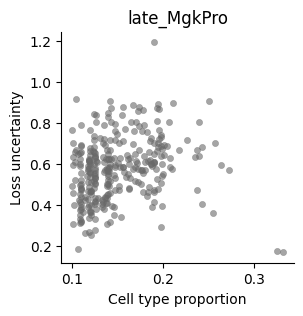

In [15]:
# sns.set(style="whitegrid", context="paper")
plt.figure(figsize=(3,3))
df_plot = filtered_df["late_MgkPro"].reset_index(drop=True)

ax = sns.scatterplot(
    data=df_plot,
    x=f"late_MgkPro_prop",
    y="uncertainty_loss",
    color="dimgray",
    legend=False,
    s=20,
    alpha=0.6,
    edgecolor=None
)

ax.set_title(cell_type)
ax.set_xlabel("Cell type proportion")
ax.set_ylabel("Loss uncertainty")

sns.despine(ax=ax)

In [16]:
sorted_mgkpro = filtered_df["late_MgkPro"].sort_values(["late_MgkPro_prop"], ascending=False).reset_index(drop=True)

In [17]:
for col in sorted_mgkpro.columns: 
    print(col)

gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
run_name
loss
uncertainty_loss
target_ct_loss_mean
uncertainty_total_variance_ct
exploitation_score
exploration_score
weighted_uncertainty_score
metric_response_surface
late_MgkPro_prop
filtering_step


In [18]:
sorted_mgkpro.loc[:, ["gm-csf_[ng_ml]",
                      "tpo_[ng_ml]", 
                      "sr1_[nm]",
                      "um171_[nm]",
                      "um729_[µm]",
                      "scf_[ng_ml]",
                      "butyzamide_[nm]",
                      "retinoic_acid_[µm]",
                      "ldl_[ng_ml]",
                      "il3_[ng_ml]",
                      "o2_[%]",
                      "days_of_culture", 
                     "late_MgkPro_prop"]]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,late_MgkPro_prop
0,0.000000,1.180005,0.000000,42.617620,0.119076,0.000000,111.774254,0.000000,0.690324,0.000000,21.341091,14.135535,0.332553
1,0.000000,1.183808,0.015878,39.386620,0.002816,0.000000,107.609820,0.453992,0.699364,0.000000,20.666897,12.284927,0.325803
2,0.000000,0.958735,0.027783,33.972992,0.000614,0.000000,115.387380,0.341541,0.489440,0.000000,21.462450,12.043622,0.272421
3,2.117040,1.117408,0.000000,89.483670,0.000000,0.000000,137.827320,0.000000,0.339360,0.000000,20.573984,16.839825,0.264631
4,1.588275,1.173371,0.000000,79.509390,0.000000,0.000000,104.143930,0.000000,0.438350,0.000000,20.749992,16.349874,0.257854
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.821721,0.263973,0.990799,110.146250,0.000000,0.000000,101.356010,0.000000,0.000000,0.053935,17.831984,14.677138,0.101074
299,0.792880,0.258437,0.967781,110.245930,0.000000,0.000000,101.918840,0.000000,0.000000,0.052519,17.773780,14.738703,0.100980
300,1.955188,0.135294,6.439604,151.193130,0.026623,0.064223,92.277664,0.000000,0.000000,0.000000,20.782665,13.744095,0.100801
301,0.780870,0.258777,0.940443,110.149320,0.000000,0.000000,101.499310,0.000000,0.000000,0.055127,17.854815,14.711877,0.100597


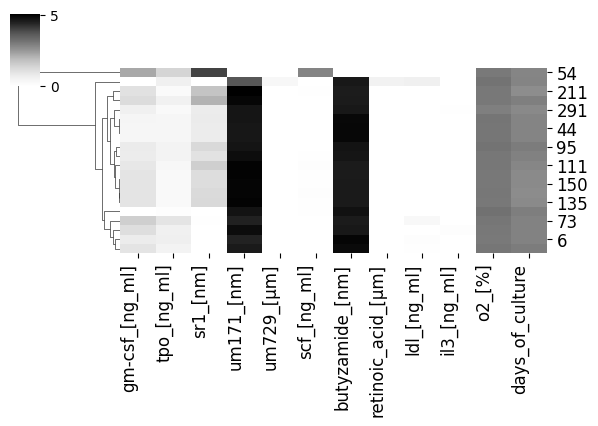

In [32]:
# sns.clustermap(
#     np.log1p(sorted_mgkpro.loc[:, protocol_cols].astype(float)),
#     row_cluster=True,
#     col_cluster=False,
#     figsize=(6, 6)
# )

# # Sort rows by late_MgkPro_prop before plotting
# sorted_df = sorted_mgkpro.sort_values(
#     by="late_MgkPro_prop",
#     ascending=True
# )

sorted_df = sorted_mgkpro.sort_values(
    by="uncertainty_loss",
    ascending=False
)

# Create clustermap
g = sns.clustermap(
    np.log1p(sorted_df[:20].loc[:, protocol_cols].astype(float)),
    row_cluster=True,
    col_cluster=False,
    figsize=(6, 4), 
    cmap="Grays"
)

# Increase tick label sizes
g.ax_heatmap.tick_params(axis='x', labelsize=12)
g.ax_heatmap.tick_params(axis='y', labelsize=12)

# Optional: rotate x labels for readability
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    ha="right"
)

# Save as SVG
g.savefig(
    "plots/mgkpro_clustermap.png",
    format="png",
    bbox_inches="tight", dpi=500, 
)
# sns.clustermap(
#     np.log1p(sorted_df[:20].sort_values("late_MgkPro_prop", ascending=True).loc[:, protocol_cols].astype(float)),
#     row_cluster=False,   # preserve sorting
#     col_cluster=False,
#     figsize=(6, 6)
# )

# Plot Sakurai pattern

In [66]:
sakurai_pattern = np.log1p(np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14]))

In [67]:
adata_original = sc.read_h5ad("../../../../../../project_folder/output/loops/data/loop0/adata_500k.h5ad")
protocol_obs = adata_original.obs.loc[:, protocol_cols].astype(float)

In [68]:
protocol_unique = {protocol: np.unique(protocol_obs[protocol]) for protocol in protocol_obs.columns}

In [69]:
mgkpro_filtered = filtered_df["late_MgkPro"].loc[:, protocol_cols]

In [70]:
for col in mgkpro_filtered.columns:
    nn_col = ((mgkpro_filtered[col].values[:, None] - protocol_unique[col][None, :])**2)
    nn_col = nn_col.argmin(-1)
    assigned = protocol_unique[col][nn_col]
    mgkpro_filtered[col] = assigned

In [71]:
mgkpro_filtered = mgkpro_filtered.drop(columns=["days_of_culture"], axis=1)

In [72]:
# filtered_df["late_MgkPro"]["is_sakurai"]  = (mgkpro_filtered==sakurai_pattern[None, :]).all(axis=1)

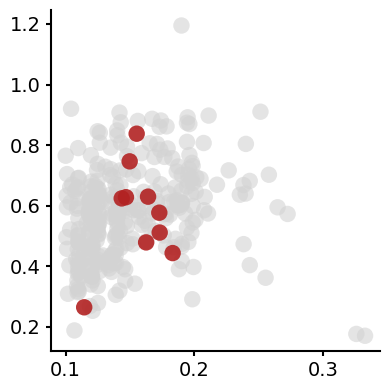

In [73]:
plt.figure(figsize=(4,4))

# Plot gray (background) points first
sns.scatterplot(
    data=filtered_df["late_MgkPro"][filtered_df["late_MgkPro"]["is_sakurai"] == False],
    x="late_MgkPro_prop",
    y="uncertainty_loss",
    color="lightgray",
    s=140,
    alpha=0.6,
    edgecolor="none",
    legend=False
)

# Plot red (highlighted) points on top
sns.scatterplot(
    data=filtered_df["late_MgkPro"][filtered_df["late_MgkPro"]["is_sakurai"] == True],
    x="late_MgkPro_prop",
    y="uncertainty_loss",
    color="firebrick",
    s=140,
    alpha=0.9,
    edgecolor="none",
    legend=False
)

plt.grid(False)
plt.xlabel("", fontsize=16)
plt.ylabel("", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14, width=1.5)

# Clean up spines to match figure style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
plt.tick_params(axis='both', which='major', labelsize=14, width=1.5, colors='black')

# Custom legend for just the highlighted group
red_dot = plt.Line2D([], [], marker='o', color='firebrick', linestyle='None',
                      markersize=12, alpha=0.9)
# plt.legend([red_dot], ["Similar to Exp. 210"], loc="upper right", frameon=True, fontsize=13)

plt.tight_layout()
plt.savefig("plots/sakurai_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Sakurai pattern heatmap 

In [74]:
sakurai_pattern_df = pd.DataFrame(sakurai_pattern)

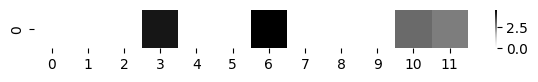

In [76]:
plt.figure(figsize=(7,0.5))
sns.heatmap(sakurai_pattern_df.T, cmap="Greys")
plt.savefig("plots/sakurai_pattern.png")